##  Threshold Tuning – Prioritizing Recall for Screening

In this step, we refine our final logistic regression models by tuning the **decision threshold** used to convert predicted probabilities into class labels ("Yes" / "No").

### Why This Matters:
- The default threshold of `0.5` may not be ideal, especially in **screening** where **recall is more important than precision**.
- We use **Youden’s J statistic** to suggest an **optimal threshold** that maximizes `(Recall + Precision - 1)`.
- We then compare model performance at both:
  -  Default Threshold (e.g., 0.5)
  -  Optimal Threshold (Youden J)

### Output:
-  Plots showing how Precision & Recall vary by threshold
-  Classification reports and confusion matrices at both thresholds
-  Saved reports and visualizations in: `5e_threshold_tuning/`

This process ensures we balance **early detection** with **false positives**, aligning the models with real-world screening priorities.


In [1]:
import os
import pandas as pd

# --- Path Config ---
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUTS_DIR = os.path.join(BASE_DIR, "outputs")
STATS_DIR = os.path.join(OUTPUTS_DIR, "statistics")
PLOTS_DIR = os.path.join(OUTPUTS_DIR, "plots")
METRICS_DIR = os.path.join(OUTPUTS_DIR, "metrics")

# Make sure subfolders exist
os.makedirs(STATS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

part18_metrics_dir = os.path.join(METRICS_DIR, "part18_threshold_tuning")
os.makedirs(part18_metrics_dir, exist_ok=True)

part18_plots_dir = os.path.join(PLOTS_DIR, "part18_threshold_tuning")
os.makedirs(part18_plots_dir, exist_ok=True)



In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix
import os

#  Threshold Tuning Function (prioritizing Recall for screening context)
def threshold_tuning_analysis(pred_csv, label, threshold=0.5):

    # Load predictions
    df = pd.read_csv(pred_csv)
    df = df.dropna(subset=["y_true"])
    y_true = df["y_true"]
    y_proba = df["y_proba"]

    # Compute precision, recall, thresholds
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)

    #  Youden's J statistic to find optimal threshold
    j_scores = recall[:-1] + precision[:-1] - 1
    best_idx = j_scores.argmax()
    best_threshold = thresholds[best_idx]
    
    # Display optimal performance (optional but informative)
    print(f"\n Youden's Optimal Threshold = {best_threshold:.2f}")
    print(f"   Precision = {precision[best_idx]:.2f}, Recall = {recall[best_idx]:.2f}")

    # ===  Plot Precision & Recall vs Threshold ===
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
    plt.plot(thresholds, recall[:-1], label="Recall", color="green")
    plt.axvline(threshold, color="red", linestyle="--", label=f"Default = {threshold}")
    plt.axvline(best_threshold, color="orange", linestyle="--", label=f"Youden = {best_threshold:.2f}")
    plt.title(f"Precision-Recall vs Threshold for {label}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    plot_path = os.path.join(part18_plots_dir, f"threshold_plot_{label.lower().replace(' ', '_')}.png")
    plt.savefig(plot_path)
    plt.show()
    print(f" Plot saved to: {plot_path}")

    # ===  Evaluation at Default Threshold ===
    print(f"\n Evaluation at Default Threshold = {threshold}")
    y_pred_default = (y_proba >= threshold).astype(int)
    print(classification_report(y_true, y_pred_default, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_default))

    # ===  Evaluation at Optimal Threshold ===
    print(f"\n Evaluation at Youden's Optimal Threshold = {best_threshold:.2f}")
    y_pred_best = (y_proba >= best_threshold).astype(int)
    print(classification_report(y_true, y_pred_best, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred_best))

    # Save reports
    report_default = pd.DataFrame(
        classification_report(y_true, y_pred_default, output_dict=True, zero_division=0)
    ).transpose()
    
    report_best = pd.DataFrame(
        classification_report(y_true, y_pred_best, output_dict=True, zero_division=0)
    ).transpose()

    report_default.to_csv(os.path.join(part18_metrics_dir, f"classification_default_{label.lower().replace(' ', '_')}.csv"))
    report_best.to_csv(os.path.join(part18_metrics_dir, f"classification_optimal_{label.lower().replace(' ', '_')}.csv"))


    print(" Classification reports saved.\n")



 Youden's Optimal Threshold = 0.23
   Precision = 0.40, Recall = 0.96


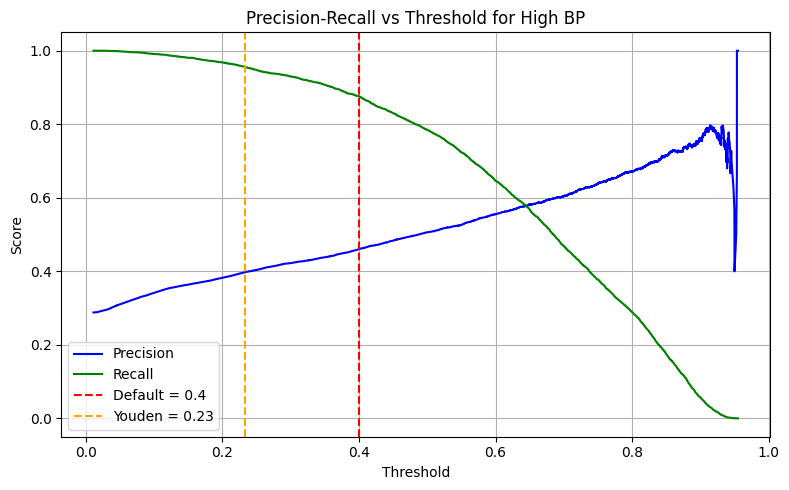

 Plot saved to: d:\Projects\health-risk-prediction\outputs\plots\part18_threshold_tuning\threshold_plot_high_bp.png

 Evaluation at Default Threshold = 0.4
              precision    recall  f1-score   support

           0       0.92      0.58      0.71     14487
           1       0.46      0.88      0.60      5864

    accuracy                           0.67     20351
   macro avg       0.69      0.73      0.66     20351
weighted avg       0.79      0.67      0.68     20351

Confusion Matrix:
 [[8458 6029]
 [ 727 5137]]

 Evaluation at Youden's Optimal Threshold = 0.23
              precision    recall  f1-score   support

           0       0.96      0.42      0.58     14487
           1       0.40      0.96      0.56      5864

    accuracy                           0.57     20351
   macro avg       0.68      0.69      0.57     20351
weighted avg       0.80      0.57      0.57     20351

Confusion Matrix:
 [[6015 8472]
 [ 256 5608]]
 Classification reports saved.


 Youden's Optim

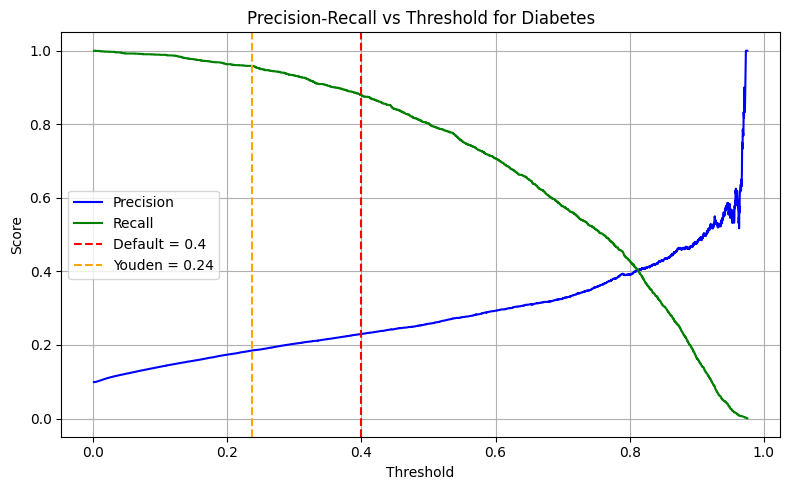

 Plot saved to: d:\Projects\health-risk-prediction\outputs\plots\part18_threshold_tuning\threshold_plot_diabetes.png

 Evaluation at Default Threshold = 0.4
              precision    recall  f1-score   support

           0       0.98      0.68      0.80     17866
           1       0.23      0.88      0.36      1965

    accuracy                           0.70     19831
   macro avg       0.61      0.78      0.58     19831
weighted avg       0.91      0.70      0.76     19831

Confusion Matrix:
 [[12077  5789]
 [  238  1727]]

 Evaluation at Youden's Optimal Threshold = 0.24
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     17866
           1       0.19      0.96      0.31      1965

    accuracy                           0.58     19831
   macro avg       0.59      0.75      0.50     19831
weighted avg       0.91      0.58      0.66     19831

Confusion Matrix:
 [[9571 8295]
 [  81 1884]]
 Classification reports saved.


 Youden's 

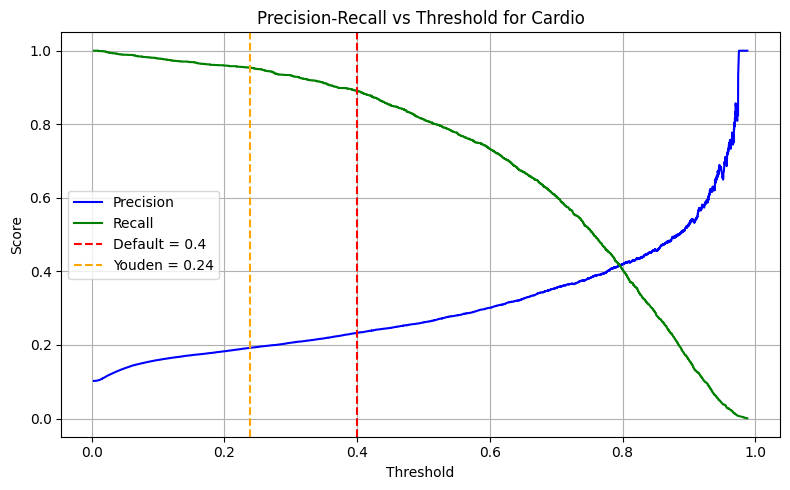

 Plot saved to: d:\Projects\health-risk-prediction\outputs\plots\part18_threshold_tuning\threshold_plot_cardio.png

 Evaluation at Default Threshold = 0.4
              precision    recall  f1-score   support

           0       0.98      0.67      0.79     17559
           1       0.23      0.89      0.37      2000

    accuracy                           0.69     19559
   macro avg       0.61      0.78      0.58     19559
weighted avg       0.91      0.69      0.75     19559

Confusion Matrix:
 [[11695  5864]
 [  218  1782]]

 Evaluation at Youden's Optimal Threshold = 0.24
              precision    recall  f1-score   support

           0       0.99      0.54      0.70     17559
           1       0.19      0.95      0.32      2000

    accuracy                           0.59     19559
   macro avg       0.59      0.75      0.51     19559
weighted avg       0.91      0.59      0.66     19559

Confusion Matrix:
 [[9541 8018]
 [  91 1909]]
 Classification reports saved.



In [4]:
threshold_tuning_analysis(
    os.path.join(STATS_DIR, "part16_roc_auc", "predictions_highbp.csv"),
    "High BP",
    threshold=0.4
)

threshold_tuning_analysis(
    os.path.join(STATS_DIR, "part16_roc_auc", "predictions_diabetes.csv"),
    "Diabetes",
    threshold=0.4
)

threshold_tuning_analysis(
    os.path.join(STATS_DIR, "part16_roc_auc", "predictions_cardio.csv"),
    "Cardio",
    threshold=0.4
)



###  Final Model Performance Summary – Default vs Youden Thresholds

| Condition      | Threshold Type | Precision (Yes) | Recall (Yes) | F1 (Yes) |
|----------------|----------------|------------------|--------------|----------|
| **High BP**    | Default        | 0.46             | 0.88         | 0.60     |
|                | Youden         | 0.40             | 0.96         | 0.56     |
| **Diabetes**   | Default        | 0.23             | 0.88         | 0.36     |
|                | Youden         | 0.19             | 0.96         | 0.31     |
| **Cardio**     | Default        | 0.23             | 0.89         | 0.37     |
|                | Youden         | 0.19             | 0.95         | 0.32     |

---

>  **Insight**: Youden’s threshold consistently increases **recall** for all three models — ensuring more at-risk individuals are identified. While precision and F1 drop slightly, this trade-off is intentional and acceptable in a **screening context**, where **missing true cases is riskier than flagging false positives**.
